---
## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    IsolationForest
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.style.use("default")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Semua library berhasil diimport")


Semua library berhasil diimport


---
## 2. Load & Inspeksi Data

In [2]:
# Sesuaikan path jika diperlukan
train = pd.read_csv("/content/Train_data.csv")
test  = pd.read_csv("/content/Test_data.csv")

print("=" * 50)
print(f"  Train : {train.shape[0]:,} baris × {train.shape[1]} kolom")
print(f"  Test  : {test.shape[0]:,} baris × {test.shape[1]} kolom")
print(f"  Missing (train) : {train.isnull().sum().sum()}")
print(f"  Missing (test)  : {test.isnull().sum().sum()}")
print(f"  Duplikat (train): {train.duplicated().sum()}")
print("=" * 50)


  Train : 25,192 baris × 42 kolom
  Test  : 22,544 baris × 41 kolom
  Missing (train) : 0
  Missing (test)  : 0
  Duplikat (train): 0


In [3]:
train.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
print("Distribusi Kelas (Train):")
print(train["class"].value_counts())
print(f"\nRasio anomaly: {(train['class']=='anomaly').mean():.3f}")


Distribusi Kelas (Train):
class
normal     13449
anomaly    11743
Name: count, dtype: int64

Rasio anomaly: 0.466


---
## 3. Exploratory Data Analysis (EDA)

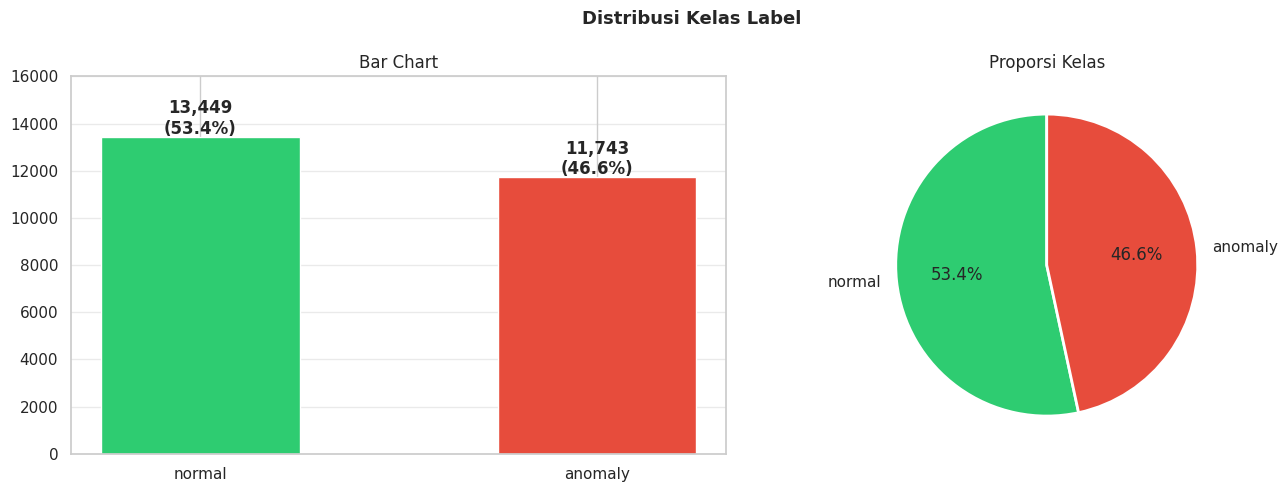

Dataset seimbang — tidak perlu SMOTE


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Kelas Label", fontsize=13, fontweight="bold")

counts = train["class"].value_counts()
colors = ["#2ECC71", "#E74C3C"]

axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.5)
for i, (v, pct) in enumerate(zip(counts.values, counts.values/len(train)*100)):
    axes[0].text(i, v + 100, f"{v:,}\n({pct:.1f}%)", ha="center", fontweight="bold")
axes[0].set_title("Bar Chart")
axes[0].set_ylim(0, 16000)
axes[0].grid(axis="y", alpha=0.4)

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proporsi Kelas")

plt.tight_layout()
plt.savefig("plot_01_distribusi_kelas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dataset seimbang — tidak perlu SMOTE")


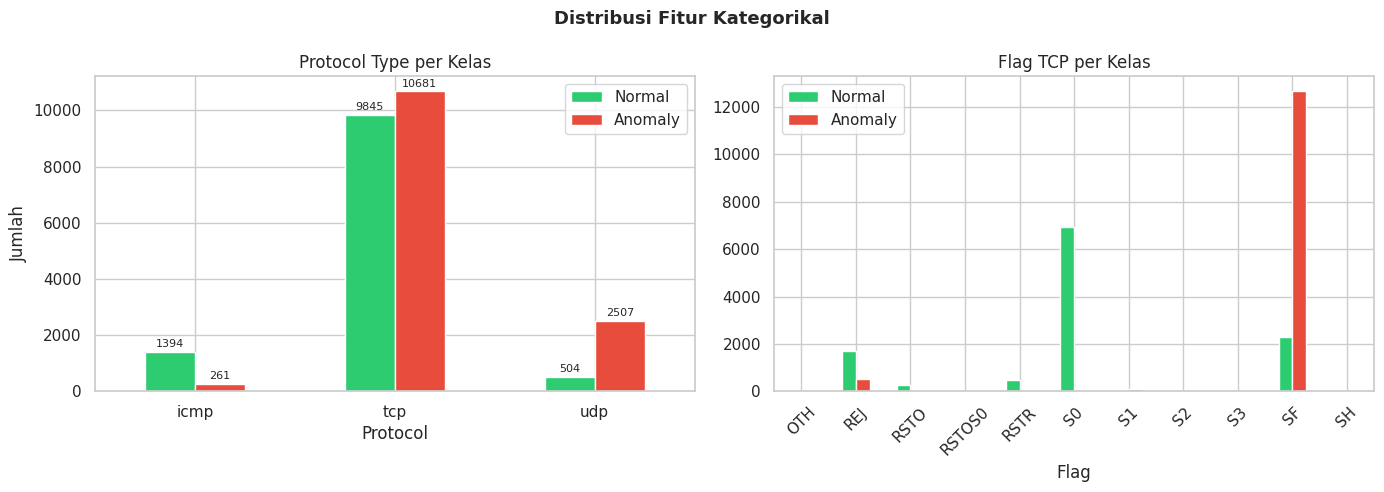

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Fitur Kategorikal", fontsize=13, fontweight="bold")

# Protocol per class
proto = train.groupby(["protocol_type","class"]).size().unstack(fill_value=0)
proto.plot(kind="bar", ax=axes[0], color=["#2ECC71","#E74C3C"],
           edgecolor="white", rot=0)
axes[0].set_title("Protocol Type per Kelas")
axes[0].set_xlabel("Protocol")
axes[0].set_ylabel("Jumlah")
axes[0].legend(["Normal","Anomaly"])
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d", fontsize=8, padding=2)

# Flag per class
flag_g = train.groupby(["flag","class"]).size().unstack(fill_value=0)
flag_g.plot(kind="bar", ax=axes[1], color=["#2ECC71","#E74C3C"],
            edgecolor="white", rot=45)
axes[1].set_title("Flag TCP per Kelas")
axes[1].set_xlabel("Flag")
axes[1].legend(["Normal","Anomaly"])

plt.tight_layout()
plt.savefig("plot_02_kategorikal.png", dpi=150, bbox_inches="tight")
plt.show()


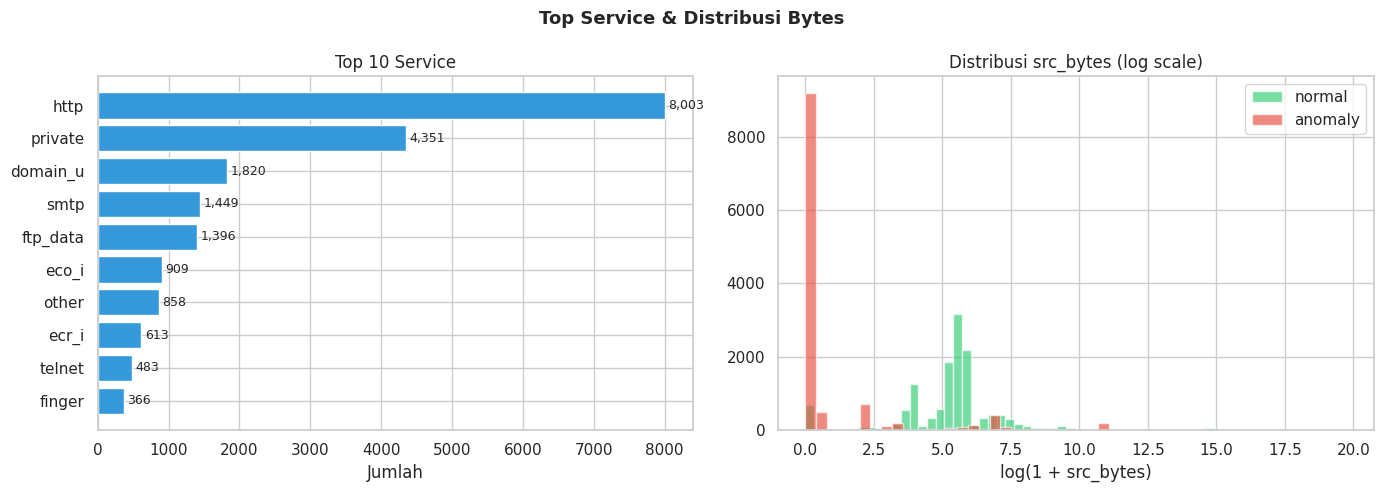

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top Service & Distribusi Bytes", fontsize=13, fontweight="bold")

# Top 10 service
top_svc = train["service"].value_counts().head(10)
axes[0].barh(top_svc.index[::-1], top_svc.values[::-1],
             color="#3498DB", edgecolor="white")
for i, v in enumerate(top_svc.values[::-1]):
    axes[0].text(v + 50, i, f"{v:,}", va="center", fontsize=9)
axes[0].set_title("Top 10 Service")
axes[0].set_xlabel("Jumlah")

# Distribusi src_bytes log scale
for cls, color in [("normal","#2ECC71"),("anomaly","#E74C3C")]:
    data = np.log1p(train[train["class"]==cls]["src_bytes"])
    axes[1].hist(data, bins=50, alpha=0.65, color=color, label=cls)
axes[1].set_title("Distribusi src_bytes (log scale)")
axes[1].set_xlabel("log(1 + src_bytes)")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_03_service_bytes.png", dpi=150, bbox_inches="tight")
plt.show()


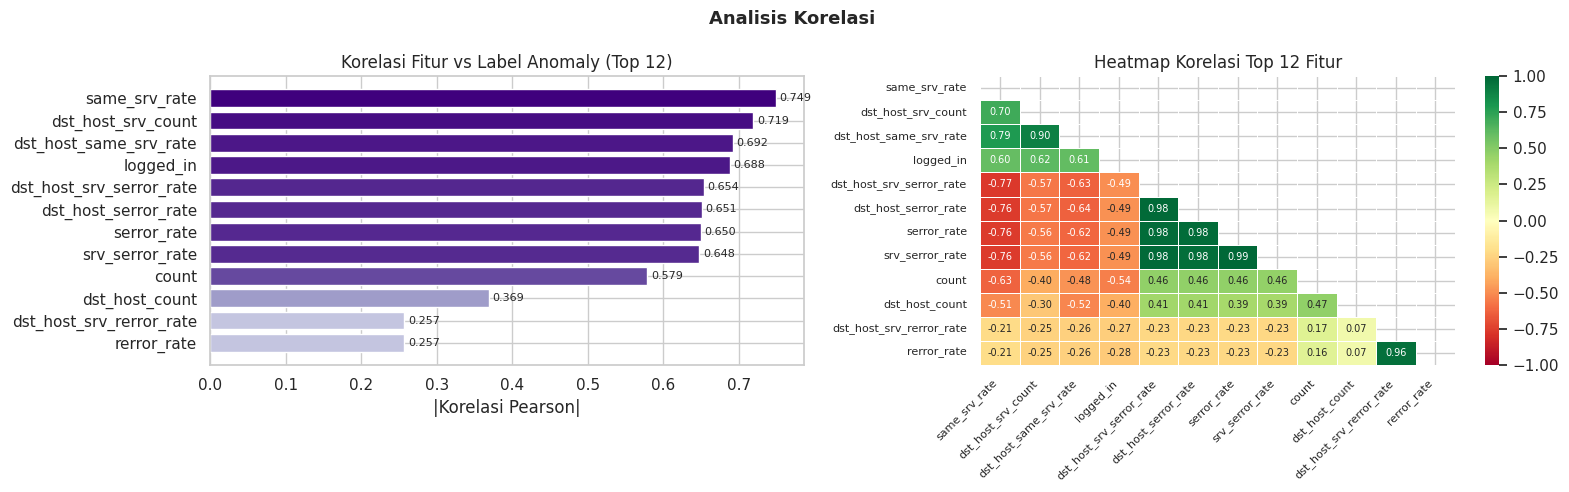


Top 5 fitur paling berkorelasi dengan label anomaly:
same_srv_rate               0.749237
dst_host_srv_count          0.719292
dst_host_same_srv_rate      0.692212
logged_in                   0.688084
dst_host_srv_serror_rate    0.653759
dtype: float64


In [8]:
# Heatmap korelasi — top 12 fitur berkorelasi dengan label
y_bin      = (train["class"] == "anomaly").astype(int)
num_cols   = train.select_dtypes(include=np.number).columns
corr_label = train[num_cols].corrwith(y_bin).abs().nlargest(12)
top12      = corr_label.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Analisis Korelasi", fontsize=13, fontweight="bold")

# Bar korelasi vs label
axes[0].barh(corr_label.index[::-1], corr_label.values[::-1],
             color=plt.cm.Purples(corr_label.values[::-1]/corr_label.max()))
axes[0].set_title("Korelasi Fitur vs Label Anomaly (Top 12)")
axes[0].set_xlabel("|Korelasi Pearson|")
for i, v in enumerate(corr_label.values[::-1]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

# Heatmap
import numpy as np
corr_mat = train[top12].corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, ax=axes[1], cmap="RdYlGn",
            center=0, annot=True, fmt=".2f", linewidths=0.5,
            annot_kws={"size":7}, vmin=-1, vmax=1)
axes[1].set_title("Heatmap Korelasi Top 12 Fitur")
axes[1].tick_params(labelsize=8)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("plot_04_korelasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nTop 5 fitur paling berkorelasi dengan label anomaly:")
print(corr_label.head())


## 4. Preprocessing


In [9]:
# ── Salin data agar original tidak termodifikasi ──────────────────────────────
df   = train.copy()
df_t = test.copy()

categorical_cols = ["protocol_type", "service", "flag"]

# ── FIX: Encoder di-fit pada GABUNGAN train+test ──────────────────────────────
# Mencegah error "unseen label" saat prediksi data baru
combined = pd.concat([df[categorical_cols], df_t[categorical_cols]])

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(combined[col])          # ← fit pada gabungan
    encoders[col] = le
    df[col]   = le.transform(df[col])
    df_t[col] = le.transform(df_t[col])

print("LabelEncoder di-fit pada data gabungan (train + test)")
for col in categorical_cols:
    print(f"   {col:<18} → {len(encoders[col].classes_)} kelas unik")


LabelEncoder di-fit pada data gabungan (train + test)
   protocol_type      → 3 kelas unik
   service            → 67 kelas unik
   flag               → 11 kelas unik


In [10]:
# ── Encode label target ───────────────────────────────────────────────────────
# anomaly=1, normal=0
target_encoder      = LabelEncoder()
df["class"]         = target_encoder.fit_transform(df["class"])

print(f"Label mapping : {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")
print(f"Rasio anomaly : {df['class'].mean():.3f}")


Label mapping : {'anomaly': np.int64(0), 'normal': np.int64(1)}
Rasio anomaly : 0.534


In [11]:
# ── Split fitur & label ───────────────────────────────────────────────────────
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = RANDOM_STATE
)

# ── FIX: Satu scaler dipakai untuk SEMUA model (termasuk IsolationForest) ─────
scaler        = StandardScaler()
X_train_s     = scaler.fit_transform(X_train)   # fit hanya pada train
X_val_s       = scaler.transform(X_val)         # transform val — NO fit
X_full_s      = scaler.transform(X)             # untuk IsolationForest

print(f"Train set  : {X_train_s.shape[0]:,} sampel")
print(f"Val set    : {X_val_s.shape[0]:,} sampel")
print(f"Full set   : {X_full_s.shape[0]:,} sampel (untuk IsolationForest)")
print(f"\n   Scaler mean (3 fitur pertama): {scaler.mean_[:3].round(4)}")
print(f"   Scaler std  (3 fitur pertama): {scaler.scale_[:3].round(4)}")


Train set  : 20,153 sampel
Val set    : 5,039 sampel
Full set   : 25,192 sampel (untuk IsolationForest)

   Scaler mean (3 fitur pertama): [289.0199   1.0524  29.0787]
   Scaler std  (3 fitur pertama): [2.5870996e+03 4.2390000e-01 1.5606900e+01]


## 5. Training & Evaluasi Model


In [12]:
import time

model_defs = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree"        : DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "K-Nearest Neighbors"  : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Random Forest"        : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

records  = []
cms      = {}
trained  = {}

print(f"{'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Time':>6}")
print("─" * 65)

for name, mdl in model_defs.items():
    t0 = time.time()
    mdl.fit(X_train_s, y_train)
    t  = time.time() - t0

    yp = mdl.predict(X_val_s)

    acc  = accuracy_score(y_val, yp)
    prec = precision_score(y_val, yp)
    rec  = recall_score(y_val, yp)
    f1   = f1_score(y_val, yp)

    records.append({
        "Model"    : name,
        "Accuracy" : round(acc  * 100, 2),   # ← simpan dalam PERSEN
        "Precision": round(prec * 100, 2),   # ← bukan desimal (fix bug 1.99)
        "Recall"   : round(rec  * 100, 2),
        "F1"       : round(f1   * 100, 2),
        "Time_s"   : round(t, 2),
    })
    cms[name]     = confusion_matrix(y_val, yp)
    trained[name] = mdl

    star = " ⭐" if name == "Random Forest" else ""
    print(f"{name+star:<27} {acc*100:>6.2f}% {prec*100:>6.2f}% {rec*100:>6.2f}% {f1*100:>6.2f}% {t:>5.1f}s")

results = pd.DataFrame(records).sort_values("F1", ascending=False).reset_index(drop=True)
best_name = results.iloc[0]["Model"]
print(f"\n⭐ Best model: {best_name} — F1={results.iloc[0]['F1']:.2f}%")


Model                         Acc    Prec     Rec      F1   Time
─────────────────────────────────────────────────────────────────
Logistic Regression          95.61%  94.94%  96.95%  95.94%   1.8s
Decision Tree                99.46%  99.52%  99.48%  99.50%   0.4s
K-Nearest Neighbors          99.48%  99.33%  99.70%  99.52%   0.0s
Random Forest ⭐              99.80%  99.67%  99.96%  99.81%   6.0s
Gradient Boosting            99.56%  99.52%  99.67%  99.59%   5.9s

⭐ Best model: Random Forest — F1=99.81%


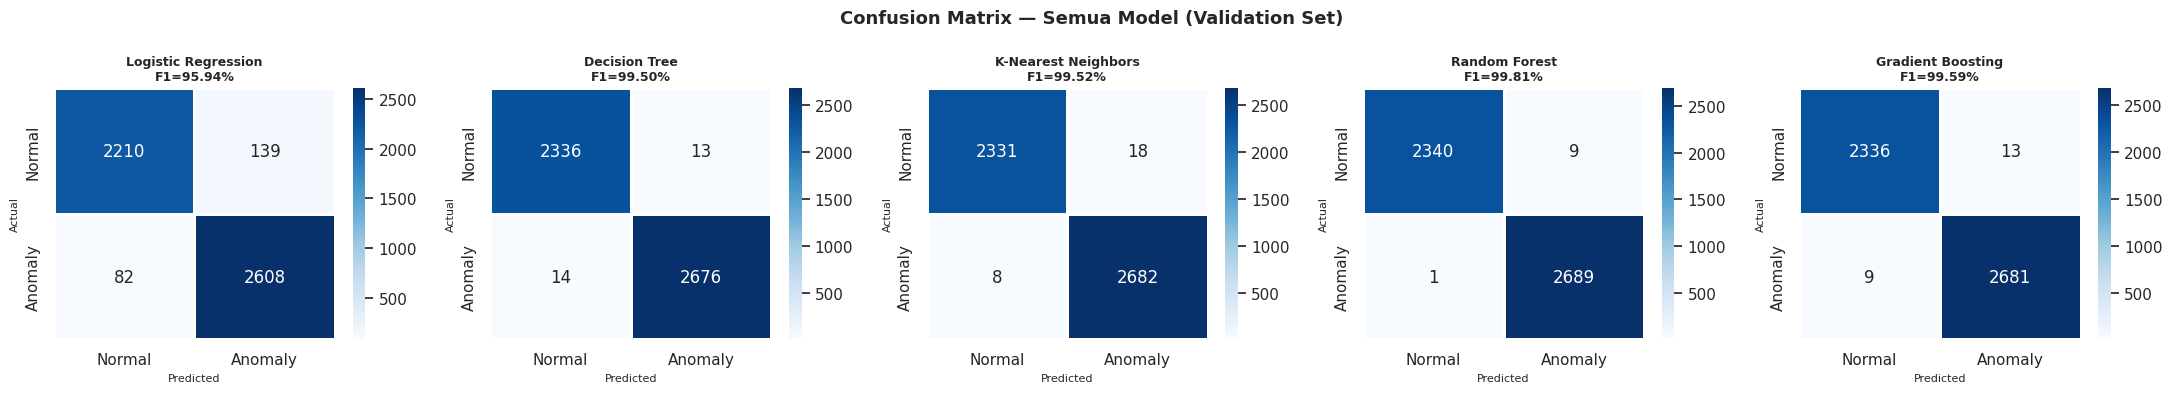

In [13]:
# ── Confusion Matrix semua model ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Confusion Matrix — Semua Model (Validation Set)", fontsize=13, fontweight="bold")

for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                cmap="Blues", linewidths=1, linecolor="white",
                xticklabels=["Normal","Anomaly"],
                yticklabels=["Normal","Anomaly"])
    f1_val = results[results["Model"]==name]["F1"].values[0]
    ax.set_title(f"{name}\nF1={f1_val:.2f}%", fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)

plt.tight_layout()
plt.savefig("plot_05_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


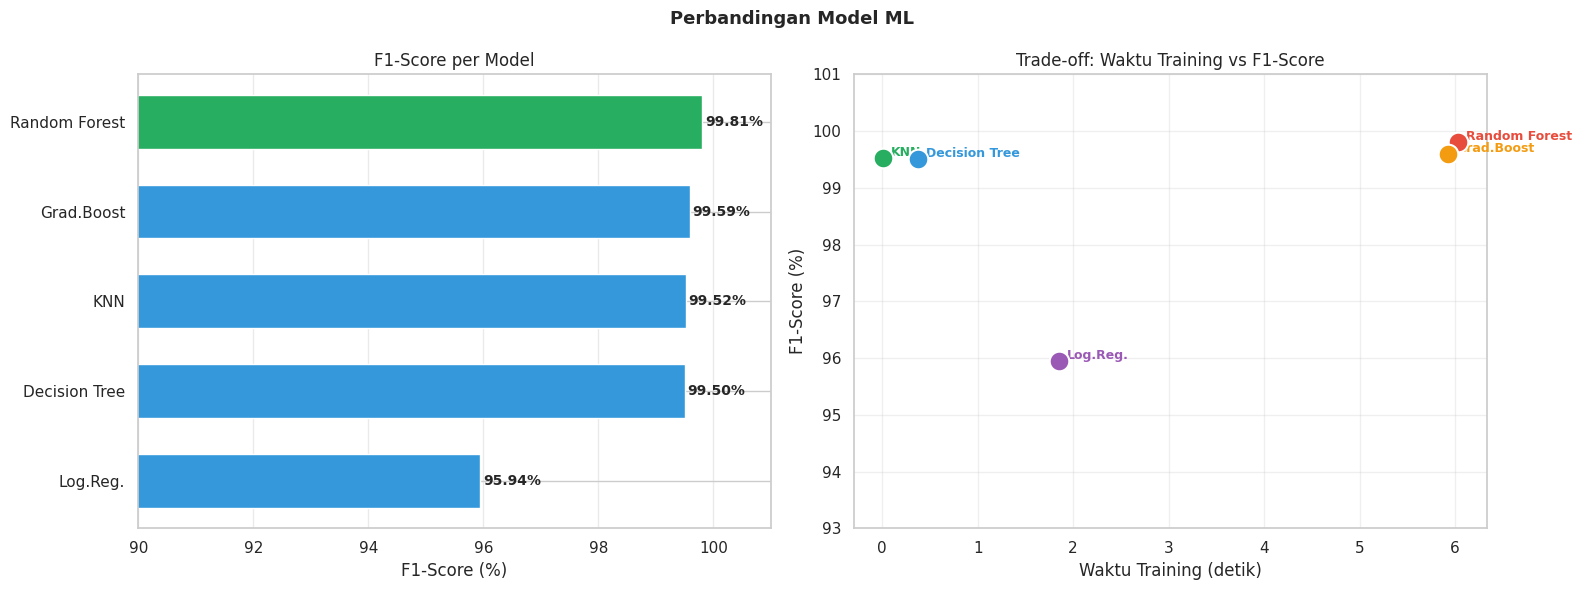

In [14]:
# ── Visualisasi perbandingan model ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Perbandingan Model ML", fontsize=13, fontweight="bold")

models_short = [n.replace("K-Nearest Neighbors","KNN")
                 .replace("Logistic Regression","Log.Reg.")
                 .replace("Gradient Boosting","Grad.Boost")
                for n in results["Model"]]
colors_bar   = ["#27AE60" if n == best_name else "#3498DB" for n in results["Model"]]

# F1-Score per model
axes[0].barh(models_short[::-1], results["F1"].values[::-1],
             color=colors_bar[::-1], edgecolor="white", height=0.6)
for i, v in enumerate(results["F1"].values[::-1]):
    axes[0].text(v + 0.05, i, f"{v:.2f}%", va="center", fontweight="bold", fontsize=10)
axes[0].set_title("F1-Score per Model")
axes[0].set_xlabel("F1-Score (%)")
axes[0].set_xlim(90, 101)
axes[0].grid(axis="x", alpha=0.4)

# Trade-off: waktu vs F1
scatter_colors = ["#E74C3C","#F39C12","#27AE60","#3498DB","#9B59B6"]
for i, row in results.iterrows():
    axes[1].scatter(row["Time_s"], row["F1"], s=200,
                    color=scatter_colors[i], zorder=5,
                    edgecolors="white", linewidth=1.5,
                    label=row["Model"])
    axes[1].annotate(
        models_short[i],
        xy=(row["Time_s"], row["F1"]),
        xytext=(row["Time_s"] + 0.08, row["F1"] + 0.04),
        fontsize=9, color=scatter_colors[i], fontweight="bold"
    )
axes[1].set_title("Trade-off: Waktu Training vs F1-Score")
axes[1].set_xlabel("Waktu Training (detik)")
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_ylim(93, 101)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot_06_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Feature Importance — Random Forest

Top 15 Feature Importance:
                    Feature  Importance
                  src_bytes    0.175810
                  dst_bytes    0.106277
                       flag    0.097893
     dst_host_same_srv_rate    0.070492
              same_srv_rate    0.066800
         dst_host_srv_count    0.060172
              diff_srv_rate    0.044070
                  logged_in    0.042377
                      count    0.037228
              protocol_type    0.037189
     dst_host_diff_srv_rate    0.033523
                    service    0.026068
dst_host_same_src_port_rate    0.024869
dst_host_srv_diff_host_rate    0.021678
            srv_serror_rate    0.021251


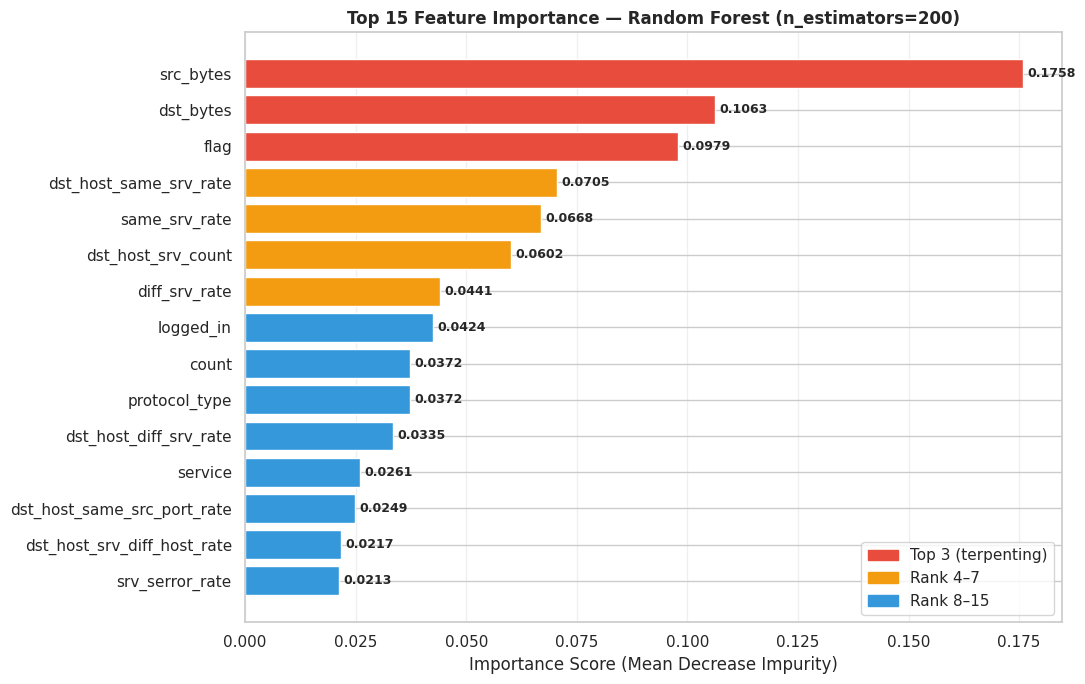

In [15]:
rf_model    = trained["Random Forest"]
importance  = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 Feature Importance:")
print(importance.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 7))
top15   = importance.head(15)
colors_fi = ["#E74C3C" if i < 3 else "#F39C12" if i < 7 else "#3498DB"
             for i in range(len(top15))]

ax.barh(top15["Feature"][::-1], top15["Importance"][::-1],
        color=colors_fi[::-1], edgecolor="white")
for i, v in enumerate(top15["Importance"][::-1]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9, fontweight="bold")
ax.set_title("Top 15 Feature Importance — Random Forest (n_estimators=200)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score (Mean Decrease Impurity)")
ax.grid(axis="x", alpha=0.3)

import matplotlib.patches as mpatches
legend_items = [
    mpatches.Patch(color="#E74C3C", label="Top 3 (terpenting)"),
    mpatches.Patch(color="#F39C12", label="Rank 4–7"),
    mpatches.Patch(color="#3498DB", label="Rank 8–15"),
]
ax.legend(handles=legend_items, loc="lower right")

plt.tight_layout()
plt.savefig("plot_07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 7. IsolationForest — Risk Score & Priority Level

### Penjelasan Dua Pendekatan Risk Score

| | Supervised (Random Forest) | Unsupervised (IsolationForest) |
|---|---|---|
| **Dasar** | Probabilitas prediksi model | Anomaly score dari isolation trees |
| **Formula** | `(1 - max_proba) × 100` | Normalisasi `decision_function` ke 0–100 |
| **Kegunaan** | Validasi performa model | Risk scoring seluruh dataset (termasuk unlabeled) |
| **Dipakai untuk** | `network_prediction.csv` | `dashboard_dataset.csv` (Looker Studio) |

> Untuk dashboard akhir digunakan **IsolationForest risk score** karena dapat diterapkan
> ke seluruh 25.192 data tanpa bergantung pada label.


In [16]:
# ── FIX: Gunakan scaler yang SAMA dengan RF (bukan scaler baru) ───────────────
# X_full_s sudah disiapkan di Cell 4 menggunakan scaler yang sama

iso = IsolationForest(
    contamination = 0.10,
    n_estimators  = 200,
    random_state  = RANDOM_STATE
)
iso.fit(X_full_s)

# Prediksi anomali (1 = normal, -1 = anomali → dikonversi ke 0/1)
df["anomaly_pred"]  = iso.predict(X_full_s)
df["anomaly_pred"]  = df["anomaly_pred"].map({1: 0, -1: 1})
df["anomaly_score"] = iso.decision_function(X_full_s)

print(f"IsolationForest selesai (scaler konsisten dengan RF)")
print(f"   Anomali terdeteksi : {(df['anomaly_pred']==1).sum():,} ({(df['anomaly_pred']==1).mean()*100:.1f}%)")
print(f"   Normal terdeteksi  : {(df['anomaly_pred']==0).sum():,}")


IsolationForest selesai (scaler konsisten dengan RF)
   Anomali terdeteksi : 2,520 (10.0%)
   Normal terdeteksi  : 22,672


In [17]:
# ── Normalisasi anomaly score ke Risk Score 0–100 ────────────────────────────
# Semakin TINGGI risk_score → semakin mencurigakan
min_s = df["anomaly_score"].min()
max_s = df["anomaly_score"].max()

df["risk_score"] = ((max_s - df["anomaly_score"]) / (max_s - min_s)) * 100

print(f"Risk Score — statistik:")
print(f"  Min  : {df['risk_score'].min():.2f}")
print(f"  Max  : {df['risk_score'].max():.2f}")
print(f"  Mean : {df['risk_score'].mean():.2f}")
print(f"  Std  : {df['risk_score'].std():.2f}")


Risk Score — statistik:
  Min  : 0.00
  Max  : 100.00
  Mean : 23.14
  Std  : 18.10


In [18]:
# ── Threat Category & Priority Level ─────────────────────────────────────────
def threat_category(score):
    if score < 25:   return "Informational"
    elif score < 50: return "Low"
    elif score < 75: return "Medium"
    else:            return "Critical"

def priority(score):
    if score < 25:   return "P4-Low"
    elif score < 50: return "P3-Medium"
    elif score < 75: return "P2-High"
    else:            return "P1-Critical"

df["ThreatCategory"] = df["risk_score"].apply(threat_category)
df["Priority"]       = df["risk_score"].apply(priority)

print("Distribusi Priority Level:")
print(df["Priority"].value_counts().to_string())
print()
print("Distribusi Threat Category:")
print(df["ThreatCategory"].value_counts().to_string())


Distribusi Priority Level:
Priority
P4-Low         16509
P3-Medium       6295
P2-High         2178
P1-Critical      210

Distribusi Threat Category:
ThreatCategory
Informational    16509
Low               6295
Medium            2178
Critical           210


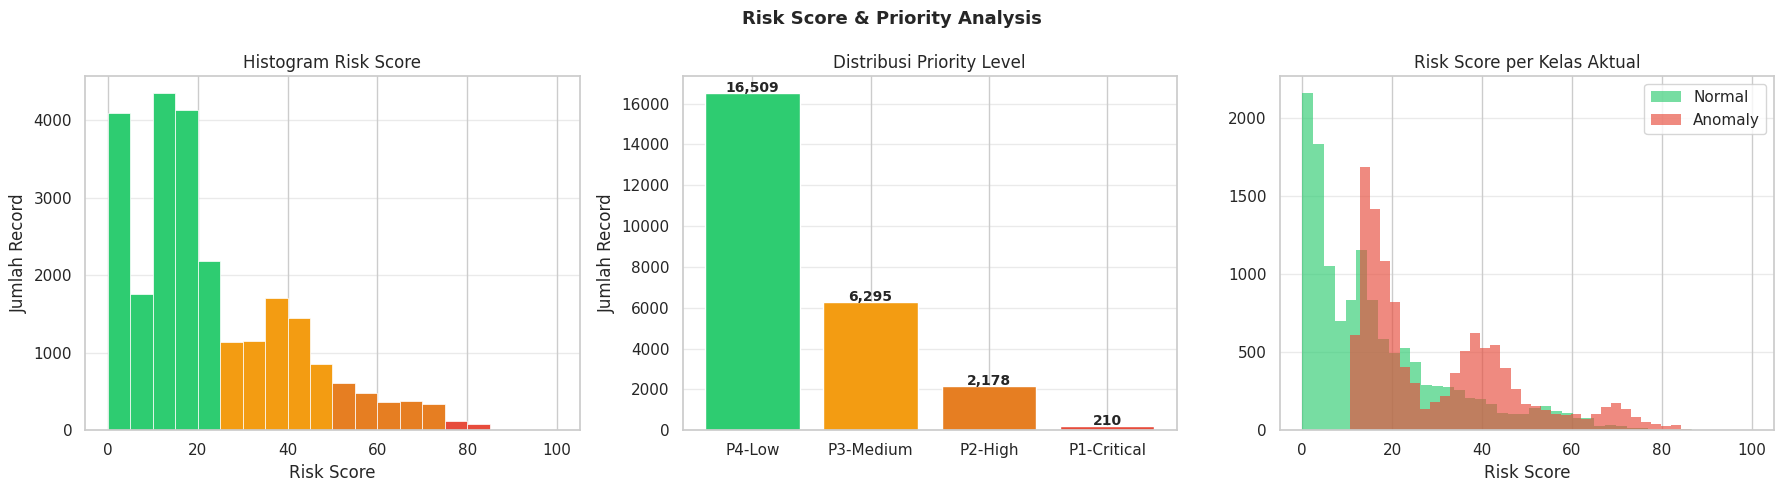

In [19]:
# ── Visualisasi Risk Score ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Risk Score & Priority Analysis", fontsize=13, fontweight="bold")

# 1. Histogram risk score
bins = list(range(0, 105, 5))
n, _, patches = axes[0].hist(df["risk_score"], bins=bins,
                              color="#3498DB", edgecolor="white", linewidth=0.5)
for patch, left in zip(patches, bins[:-1]):
    if left < 25:   patch.set_facecolor("#2ECC71")
    elif left < 50: patch.set_facecolor("#F39C12")
    elif left < 75: patch.set_facecolor("#E67E22")
    else:           patch.set_facecolor("#E74C3C")
axes[0].set_title("Histogram Risk Score")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Jumlah Record")
axes[0].grid(axis="y", alpha=0.4)

# 2. Distribusi Priority
prio_counts  = df["Priority"].value_counts()
prio_order   = ["P4-Low","P3-Medium","P2-High","P1-Critical"]
prio_colors  = ["#2ECC71","#F39C12","#E67E22","#E74C3C"]
prio_vals    = [prio_counts.get(p, 0) for p in prio_order]
bars = axes[1].bar(prio_order, prio_vals, color=prio_colors, edgecolor="white")
for bar, v in zip(bars, prio_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f"{v:,}", ha="center", fontweight="bold", fontsize=10)
axes[1].set_title("Distribusi Priority Level")
axes[1].set_ylabel("Jumlah Record")
axes[1].grid(axis="y", alpha=0.4)

# 3. Risk score per class (actual label)
orig_class = train["class"].values
for cls, color, label in [("normal","#2ECC71","Normal"),("anomaly","#E74C3C","Anomaly")]:
    mask = orig_class == cls
    axes[2].hist(df.loc[mask, "risk_score"], bins=40,
                 alpha=0.65, color=color, label=label, edgecolor="none")
axes[2].set_title("Risk Score per Kelas Aktual")
axes[2].set_xlabel("Risk Score")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("plot_08_risk_score.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Membuat Dashboard Dataset untuk Looker Studio


In [20]:
# ── Dataset utama untuk Looker Studio ────────────────────────────────────────
dashboard_dataset = train.copy()
dashboard_dataset["risk_score"]      = df["risk_score"].values
dashboard_dataset["ThreatCategory"]  = df["ThreatCategory"].values
dashboard_dataset["Priority"]        = df["Priority"].values
dashboard_dataset["anomaly_pred"]    = df["anomaly_pred"].values

print(f"dashboard_dataset shape : {dashboard_dataset.shape}")
print(f"Kolom baru : risk_score, ThreatCategory, Priority, anomaly_pred")


dashboard_dataset shape : (25192, 46)
Kolom baru : risk_score, ThreatCategory, Priority, anomaly_pred


In [21]:
# ── Security Health Index ─────────────────────────────────────────────────────
security_df           = df.copy()
security_health_index = round(100 - security_df["risk_score"].mean(), 2)

print(f"Security Health Index : {security_health_index}")
print(f"  (100 - rata-rata risk_score = 100 - {security_df['risk_score'].mean():.2f})")
print()
print("Interpretasi:")
if security_health_index >= 80: print("SEHAT — risiko rendah")
elif security_health_index >= 60: print("WASPADA — risiko moderat")
else: print("KRITIS — risiko tinggi")


Security Health Index : 76.86
  (100 - rata-rata risk_score = 100 - 23.14)

Interpretasi:
WASPADA — risiko moderat


In [22]:
# ── Prediction DF dari Random Forest ─────────────────────────────────────────
# (untuk tab ML di Looker Studio)
rf_best    = trained["Random Forest"]
rf_pred_val = rf_best.predict(X_val_s)
rf_prob_val = rf_best.predict_proba(X_val_s).max(axis=1)

prediction_df = pd.DataFrame({
    "Actual"     : y_val.values,
    "Prediction" : rf_pred_val,
    "Probability": rf_prob_val.round(4),
    # FIX: RiskScore_RF = confidence model dalam prediksi anomaly
    # Beda dengan IsolationForest risk_score — lihat penjelasan di Cell 7
    "RiskScore_RF": ((1 - rf_best.predict_proba(X_val_s)[:, 1]) * 100).round(2),
})
prediction_df["RiskLevel_RF"] = prediction_df["RiskScore_RF"].apply(
    lambda s: "Low" if s < 30 else "Medium" if s < 70 else "High"
)

print(f"prediction_df shape : {prediction_df.shape}")
print(prediction_df.head())


prediction_df shape : (5039, 5)
   Actual  Prediction  Probability  RiskScore_RF RiskLevel_RF
0       0           0          1.0         100.0         High
1       1           1          1.0           0.0          Low
2       0           0          1.0         100.0         High
3       0           0          1.0         100.0         High
4       1           1          1.0           0.0          Low


## 9. Export CSV untuk Looker Studio

In [23]:
# ── FIX TOP RISK RECORDS ──────────────────────────────────────────────────────
# Sort DESCENDING → record dengan risk_score tertinggi di atas
top_risk = (
    dashboard_dataset
    .sort_values("risk_score", ascending=False)   # ← FIX: was ascending=True sebelumnya
    .head(100)
    [["protocol_type","service","flag","src_bytes","dst_bytes",
      "risk_score","ThreatCategory","Priority","class"]]
    .reset_index(drop=True)
)

print("Top 5 Record Risiko TERTINGGI:")
print(top_risk[["protocol_type","service","flag","risk_score","Priority"]].head())


Top 5 Record Risiko TERTINGGI:
  protocol_type service  flag  risk_score     Priority
0           tcp  telnet    SF  100.000000  P1-Critical
1           tcp  telnet  RSTO   96.321734  P1-Critical
2           tcp  telnet    SF   95.274869  P1-Critical
3           tcp     IRC    S3   91.397707  P1-Critical
4           tcp     ftp    SF   90.834670  P1-Critical


In [24]:
# ── Export semua file ─────────────────────────────────────────────────────────
export_path = "/content/"   # Ganti jika diperlukan

# 1. Model performance — dalam PERSEN (fix bug 1.99)
results.to_csv(f"{export_path}model_performance.csv", index=False)

# 2. Feature importance
importance.to_csv(f"{export_path}feature_importance.csv", index=False)

# 3. RF prediction results (validation set)
prediction_df.to_csv(f"{export_path}network_prediction.csv", index=False)

# 4. Full dataset dengan risk score (IsolationForest)
security_df.to_csv(f"{export_path}security_intelligence.csv", index=False)

# 5. Dashboard dataset utama
dashboard_dataset.to_csv(f"{export_path}dashboard_dataset.csv", index=False)

# 6. Top 100 highest risk records (sort descending — FIX)
top_risk.to_csv(f"{export_path}top_risk_records.csv", index=False)

# 7. Summary KPI
dashboard_summary = pd.DataFrame([{
    "TotalTraffic"        : len(security_df),
    "AnomalyCount"        : int((security_df["anomaly_pred"] == 1).sum()),
    "NormalCount"         : int((security_df["anomaly_pred"] == 0).sum()),
    "CriticalThreatCount" : int((security_df["Priority"] == "P1-Critical").sum()),
    "HighRiskCount"       : int((security_df["Priority"] == "P2-High").sum()),
    "SecurityHealthIndex" : security_health_index,
    "AverageRiskScore"    : round(security_df["risk_score"].mean(), 2),
    # FIX: Metrics dalam persen — cocok langsung di Looker tanpa konversi
    "RF_Accuracy_pct"     : results[results["Model"]=="Random Forest"]["Accuracy"].values[0],
    "RF_Precision_pct"    : results[results["Model"]=="Random Forest"]["Precision"].values[0],
    "RF_Recall_pct"       : results[results["Model"]=="Random Forest"]["Recall"].values[0],
    "RF_F1_pct"           : results[results["Model"]=="Random Forest"]["F1"].values[0],
}])

dashboard_summary.to_csv(f"{export_path}dashboard_summary.csv", index=False)

print("=" * 55)
print("  SEMUA FILE BERHASIL DIEXPORT")
print("=" * 55)
files = [
    ("model_performance.csv",    "Perbandingan 5 model (dalam %)"),
    ("feature_importance.csv",   "Feature importance RF"),
    ("network_prediction.csv",   "Prediksi RF + RiskScore_RF"),
    ("security_intelligence.csv","Full dataset + IsoForest score"),
    ("dashboard_dataset.csv",    "Dataset utama Looker Studio"),
    ("top_risk_records.csv",     "100 record risiko TERTINGGI ↓"),
    ("dashboard_summary.csv",    "KPI ringkasan untuk cards"),
]
for fname, desc in files:
    print(f"{fname:<35} → {desc}")


  SEMUA FILE BERHASIL DIEXPORT
model_performance.csv               → Perbandingan 5 model (dalam %)
feature_importance.csv              → Feature importance RF
network_prediction.csv              → Prediksi RF + RiskScore_RF
security_intelligence.csv           → Full dataset + IsoForest score
dashboard_dataset.csv               → Dataset utama Looker Studio
top_risk_records.csv                → 100 record risiko TERTINGGI ↓
dashboard_summary.csv               → KPI ringkasan untuk cards


## 10. Kesimpulan

In [25]:
# ── Verifikasi final ──────────────────────────────────────────────────────────
import os
files_check = [
    "model_performance.csv",
    "feature_importance.csv",
    "network_prediction.csv",
    "security_intelligence.csv",
    "dashboard_dataset.csv",
    "top_risk_records.csv",
    "dashboard_summary.csv",
]

print("VERIFIKASI FILE OUTPUT")
print("=" * 50)
for f in files_check:
    path = f"/content/{f}"
    if os.path.exists(path):
        df_check = pd.read_csv(path)
        print(f"{f:<38} {df_check.shape[0]:>6,} baris × {df_check.shape[1]} kolom")
    else:
        print(f"{f} — TIDAK DITEMUKAN")

print("\nNotebook selesai — semua file siap untuk Looker Studio!")
print(f"   Security Health Index : {security_health_index}")
rf_row = results[results['Model']=='Random Forest'].iloc[0]
print(f"   RF Accuracy           : {rf_row['Accuracy']:.2f}%")
print(f"   RF F1-Score           : {rf_row['F1']:.2f}%")


VERIFIKASI FILE OUTPUT
model_performance.csv                       5 baris × 6 kolom
feature_importance.csv                     41 baris × 2 kolom
network_prediction.csv                  5,039 baris × 5 kolom
security_intelligence.csv              25,192 baris × 47 kolom
dashboard_dataset.csv                  25,192 baris × 46 kolom
top_risk_records.csv                      100 baris × 9 kolom
dashboard_summary.csv                       1 baris × 11 kolom

Notebook selesai — semua file siap untuk Looker Studio!
   Security Health Index : 76.86
   RF Accuracy           : 99.80%
   RF F1-Score           : 99.81%


In [26]:
#  Export data baru untuk chart baru di looker

# ── 1. Correlation Matrix (untuk Heatmap Korelasi) ────────
num_cols   = train.select_dtypes(include=np.number).columns
y_bin      = (train["class"] == "anomaly").astype(int)
corr_label = train[num_cols].corrwith(y_bin).abs().nlargest(12)
top12_cols = corr_label.index.tolist()

corr_matrix = train[top12_cols].corr().round(3)

# Format panjang (long format) — lebih mudah dibaca Looker
corr_long = (
    corr_matrix
    .reset_index()
    .melt(id_vars="index", var_name="Feature_B", value_name="Correlation")
    .rename(columns={"index": "Feature_A"})
)
corr_long["Abs_Correlation"] = corr_long["Correlation"].abs().round(3)
corr_long.to_csv("/content/correlation_matrix.csv", index=False)
print(f"✅ correlation_matrix.csv — {len(corr_long)} baris")

# ── 2. Feature × Model Importance (untuk Heatmap F×M) ────
feat_model_rows = []
for name, mdl in trained.items():
    if hasattr(mdl, "feature_importances_"):
        for feat, imp in zip(X.columns, mdl.feature_importances_):
            feat_model_rows.append({
                "Model"      : name,
                "Feature"    : feat,
                "Importance" : round(float(imp), 4),
            })

feat_model_df = pd.DataFrame(feat_model_rows)

# Hanya top 10 fitur berdasarkan RF agar heatmap tidak terlalu penuh
top10_feats = (
    feat_model_df[feat_model_df["Model"] == "Random Forest"]
    .nlargest(10, "Importance")["Feature"]
    .tolist()
)
feat_model_filtered = feat_model_df[feat_model_df["Feature"].isin(top10_feats)]
feat_model_filtered.to_csv("/content/feature_model_importance.csv", index=False)
print(f"✅ feature_model_importance.csv — {len(feat_model_filtered)} baris")

# ── 3. Service × Class (untuk Bubble Chart) ───────────────
service_stats = (
    train.groupby("service")
    .agg(
        Total      = ("class", "count"),
        Anomaly    = ("class", lambda x: (x == "anomaly").sum()),
        Normal     = ("class", lambda x: (x == "normal").sum()),
    )
    .reset_index()
)
service_stats["Anomaly_Rate"] = (
    service_stats["Anomaly"] / service_stats["Total"] * 100
).round(2)
service_stats = service_stats.nlargest(15, "Total")
service_stats.to_csv("/content/service_stats.csv", index=False)
print(f"✅ service_stats.csv — {len(service_stats)} baris")

# ── 4. Risk Bucket (untuk Area Chart) ────────────────────
bins        = list(range(0, 105, 5))
labels      = [f"[{i},{i+5})" for i in bins[:-1]]
bucket_col  = pd.cut(
    security_df["risk_score"], bins=bins, labels=labels, right=False
)
risk_bucket = (
    bucket_col.value_counts()
    .sort_index()
    .reset_index()
)
risk_bucket.columns = ["Risk_Bucket", "Record_Count"]
risk_bucket["Bucket_Start"] = bins[:-1]
risk_bucket.to_csv("/content/risk_distribution.csv", index=False)
print(f"risk_distribution.csv — {len(risk_bucket)} baris")

print("\nSemua file tambahan siap diupload ke Looker Studio!")

✅ correlation_matrix.csv — 144 baris
✅ feature_model_importance.csv — 30 baris
✅ service_stats.csv — 15 baris
risk_distribution.csv — 20 baris

Semua file tambahan siap diupload ke Looker Studio!
